In [ ]:
import numpy as np
tour = [1, 2, 3, 4, 5]

In [ ]:
tour_shifted = np.roll(tour, -1)
tour_shifted

In [ ]:
def tour_distance(tour, dist_matrix):
    tour_shifted = np.roll(tour, -1)
    return np.sum(np.asarray(dist_matrix)[tour, tour_shifted])

In [ ]:
import numpy as np

tour = np.array([0, 1, 2, 3, 4, 5, 6])  # visits all 7 cities then returns to 0
dist_matrix = np.array([
    [0, 10, 20, 25, 31, 40, 42],
    [10, 0, 15, 22, 27, 33, 35],
    [20, 15, 0, 18, 24, 30, 32],
    [25, 22, 18, 0, 16, 26, 28],
    [31, 27, 24, 16, 0, 21, 23],
    [40, 33, 30, 26, 21, 0, 19],
    [42, 35, 32, 28, 23, 19, 0],
])

total = tour_distance(tour, dist_matrix)
print(total)

## Testing 2-opt

In [ ]:
tour

In [ ]:
def two_opt(tour, i, j):
    print("tour:", tour, "i:", i, "j:", j)
    print("tour segment to be reversed:", tour[i:j+1])
    new_tour = np.concatenate((tour[:i], tour[i:j+1][::-1], tour[j+1:]))
    return new_tour

In [ ]:
def _two_opt_first_improvement(tour: np.ndarray) -> tuple[np.ndarray, bool]:
    current_distance = 10
    length = len(tour) - 1 if tour[0] == tour[-1] else len(tour)
    for i in range(1, length - 1):
        for j in range(i + 1, length):
            if j - i == 1:
                continue
            candidate = two_opt(tour, i, j)
            print("New tour:", candidate)
            candidate_distance = 11
            if candidate_distance < current_distance:
                return candidate, True
    return tour, False

In [ ]:
_two_opt_first_improvement(tour)

In [ ]:
is_closed = tour[0] == tour[-1]
length = len(tour) - 1 if is_closed else len(tour)

def edge_cost(u: int, v: int) -> float:
    lower, upper = (u, v) if u <= v else (v, u)
    return dist_matrix[lower, upper]

core = tour[:-1] if is_closed else tour

In [ ]:
for i in range(1, length - 1):
    for j in range(i + 1, length):
        if j - i == 1:
            continue
        
        print("i:", i, "j:", j)
        a, b = core[i - 1], core[i]
        c, d = core[j], core[(j + 1) % length]
        print("a, b, c, d:", a, b, c, d)

        removed = edge_cost(a, b) + edge_cost(c, d)
        added = edge_cost(a, c) + edge_cost(b, d)
        delta = added - removed
        

In [ ]:
def double_bridge_move(tour: np.ndarray, a: int, b: int, c: int, d: int) -> np.ndarray:
    """Apply a double-bridge move defined by four cut indices."""
    if len(tour) < 6:
        return tour.copy()

    is_closed = tour[0] == tour[-1]
    core = tour[:-1] if is_closed else tour
    n = len(core)
    print("Core:", core)
    if n < 6:
        return tour.copy()

    segment_1 = core[:a]
    segment_2 = core[a:b]
    segment_3 = core[b:c]
    segment_4 = core[c:d]
    segment_5 = core[d:]
    print("Segments:", segment_1, segment_2, segment_3, segment_4, segment_5)

    new_core = np.concatenate((segment_1, segment_3, segment_2, segment_4, segment_5))
    if is_closed:
        new_core = np.concatenate((new_core, [new_core[0]]))
    return new_core

### One insertion

In [ ]:
def one_insertion(tour: np.ndarray, i: int, j: int) -> np.ndarray:
    """Remove the vertex at position i and insert it before position j."""
    if i == j:
        return tour.copy()

    is_closed = tour[0] == tour[-1]
    core = tour[:-1] if is_closed else tour
    new_core = core.copy()
    city = new_core[i]
    new_core = np.delete(new_core, i)
    print("tour:", tour, "i:", i, "j:", j, "new_core before insertion:", new_core)
    if j > i:
        j -= 1
    new_core = np.insert(new_core, j, city)
    if is_closed:
        return np.concatenate((new_core, [new_core[0]]))
    print("new_core after insertion:", new_core)
    return new_core

In [ ]:
def _one_insertion_first_improvement(
    tour: np.ndarray, current_distance: float
) -> tuple[np.ndarray, bool]:
    length = len(tour) - 1 if tour[0] == tour[-1] else len(tour)
    if length < 3:
        return tour, False, current_distance

    for i in range(1, length):
        for j in range(1, length + 1):
            if i == j or j == i + 1:
                continue
            candidate = one_insertion(tour, i, j)
            candidate_distance = tour_distance(candidate, dist_matrix)
            if candidate_distance < current_distance:
                print("Improvement found:", candidate_distance, "<", current_distance)
                    
    print("No improvement found")   
    return tour, False

In [ ]:
tour_distance(tour, dist_matrix)

In [ ]:
_one_insertion_first_improvement(tour, 141)

In [ ]:
def _one_insertion_first_test(
     tour: np.ndarray, current_distance: float
) -> tuple[np.ndarray, bool, float]:
    """Return the first improving 1-insertion move using edge deltas."""

    is_closed = tour[0] == tour[-1]
    core = tour[:-1] if is_closed else tour
    length = len(core)
    if length < 3:
        return tour, False, current_distance

    def edge_cost(u: int, v: int) -> float:
        lower, upper = (u, v) if u <= v else (v, u)
        return dist_matrix[lower, upper]

    for i in range(1, length):
        city = core[i]
        prev_i = core[i - 1] if i > 0 else (core[-1] if is_closed else None)
        next_i = core[(i + 1) % length] if (is_closed or i + 1 < length) else None

        removal_delta = 0.0
        if prev_i is not None:
            removal_delta -= edge_cost(prev_i, city)
        if next_i is not None:
            removal_delta -= edge_cost(city, next_i)
            if prev_i is not None:
                removal_delta += edge_cost(prev_i, next_i)

        core_removed = np.delete(core, i)
        reduced_len = len(core_removed)
        if reduced_len == 0:
            continue

        for j in range(1, length + 1):
            if i == j or j == i + 1:
                continue

            insert_idx = j
            if insert_idx > i:
                insert_idx -= 1

            if insert_idx < 0 or insert_idx > reduced_len:
                continue

            if is_closed:
                prev_new = core_removed[(insert_idx - 1) % reduced_len]
                next_new = core_removed[insert_idx % reduced_len]
            else:
                prev_new = core_removed[insert_idx - 1] if insert_idx > 0 else None
                next_new = core_removed[insert_idx] if insert_idx < reduced_len else None

            insertion_delta = 0.0
            if prev_new is not None and next_new is not None:
                insertion_delta -= edge_cost(prev_new, next_new)
            if prev_new is not None:
                insertion_delta += edge_cost(prev_new, city)
            if next_new is not None:
                insertion_delta += edge_cost(city, next_new)

            delta = removal_delta + insertion_delta
            print("i:", i, "j:", j, "delta:", delta)
            if delta < 0:
                new_distance = current_distance + delta
                candidate = one_insertion(tour, i, j)
                print("Improvement found:", new_distance, "<", current_distance)
                return candidate, True, new_distance

    return tour, False, current_distance

In [ ]:
_one_insertion_first_test(tour, 141)

In [ ]:
def _double_bridge_first_improvement(tour: np.ndarray) -> tuple[np.ndarray, bool]:
    current_distance = 10
    is_closed = tour[0] == tour[-1]
    length = len(tour) - 1 if is_closed else len(tour)
    if length < 6:
        return tour, False

    for a in range(1, length - 3):
        for b in range(a + 1, length - 2):
            for c in range(b + 1, length - 1):
                for d in range(c + 1, length):
                    print("Current tour:", tour, "Cuts:", a, b, c, d)
                    candidate = double_bridge_move(tour, a, b, c, d)
                    print("New tour:", candidate)
                    candidate_distance = 11
                    if candidate_distance < current_distance:
                        return candidate, True
    return tour, False

In [ ]:
_double_bridge_first_improvement(tour)

In [ ]:
def _reward_matrix(distance_matrix: np.ndarray) -> np.ndarray:
	"""Build the reward matrix r(s,a) = M_i / d_ij as described in the paper."""
	with np.errstate(divide="ignore"):
		mean_dist = distance_matrix.mean(axis=1)
		print(mean_dist)
		rewards = np.divide(mean_dist[:, None], distance_matrix, where=distance_matrix > 0)
	rewards[np.isinf(rewards)] = 0.0
	rewards[np.isnan(rewards)] = 0.0
	return rewards




## Testing q-learning initial solution

In [1]:
import sys
from pathlib import Path
import numpy as np

repo_root = Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
src_dir = repo_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))
src_dir

from pathlib import Path
import numpy as np

from src.structures.graph import Graph
from src.solver.initial_solution import q_learning_tour, QLearningConfig, nearest_neighbour_tour

In [3]:
def _reward_matrix(distance_matrix: np.ndarray) -> np.ndarray:
    """Build the reward matrix r(s,a) = M_i / d_ij as described in the paper."""
    with np.errstate(divide="ignore"):
        mean_dist = distance_matrix.mean(axis=1)
        print("Mean distance:", mean_dist)
        rewards = np.divide(
            distance_matrix, mean_dist[:, None], where=mean_dist[:, None] > 0
        )
    rewards[np.isinf(rewards)] = 0.0
    rewards[np.isnan(rewards)] = 0.0
    return rewards


In [4]:
def _reward_matrix(distance_matrix: np.ndarray) -> np.ndarray:
    """Build the reward matrix r(s,a) = M_i / d_ij as described in the paper."""
    with np.errstate(divide="ignore"):
        mean_dist = distance_matrix.mean(axis=1)
        rewards = np.divide(
            mean_dist[:, None], distance_matrix, where=distance_matrix > 0
        )
    rewards[np.isinf(rewards)] = 0.0
    rewards[np.isnan(rewards)] = 0.0
    return rewards

In [5]:
instance_path = Path("/Users/karinaassiniandreatta/Documents/01 phd/codes/tsp_rl_metaheuristic/instances/tsplib/pcb442.tsp")
graph = Graph.from_tsplib(instance_path)
distance_full = np.asarray(graph.build_adj_matrix_full(), dtype=float)
distance_matrix = np.asarray(graph._build_adj_matrix(), dtype=float)

#### Reward matrix test

In [6]:
import numpy as np

sample_dist = np.array([
    [0.0, 2.0, 4.0],
    [2.0, 0.0, 6.0],
    [4.0, 6.0, 0.0],
])

sample_rewards = _reward_matrix(sample_dist)
sample_rewards

array([[0.        , 1.        , 0.5       ],
       [1.33333333, 0.        , 0.44444444],
       [0.83333333, 0.55555556, 0.        ]])

In [7]:
2/ 2.66666667

0.7499999990624999

In [8]:
distance_full

array([[   0.,  100.,  200., ..., 2370.,  557.,  447.],
       [ 100.,    0.,  100., ..., 2359.,  550.,  539.],
       [ 200.,  100.,    0., ..., 2353.,  561.,  632.],
       ...,
       [2370., 2359., 2353., ...,    0., 1813., 2647.],
       [ 557.,  550.,  561., ..., 1813.,    0.,  896.],
       [ 447.,  539.,  632., ..., 2647.,  896.,    0.]], shape=(442, 442))

In [9]:
def tour_distance(tour, dist_matrix):
    tour = np.asarray(tour, dtype=int)
    tour_shifted = np.roll(tour, -1)
    lower = np.minimum(tour, tour_shifted)
    upper = np.maximum(tour, tour_shifted)
    return float(np.sum(dist_matrix[lower, upper]))

In [10]:
# Select the best action based on the Q-values -> epsilon-greedy
# _epsilon_greedy_action

# Toy Q-table: rows = states, columns = actions
q_table = np.array([
    [0.5, 0.9, 0.8, 0.1, 0.2],
    [0.6, 0.2, 0.4, 0.7, 0.3],
    [0.3, 0.5, 0.6, 0.2, 0.4],
    [0.4, 0.1, 0.3, 0.9, 0.5],
    [0.2, 0.8, 0.7, 0.5, 0.6],
])

available_actions = [0, 1, 2, 3, 4]
state = 0
q_values = q_table[state]
print(q_values)
best_action = max(available_actions, key=lambda action: q_values[action])
best_action

[0.5 0.9 0.8 0.1 0.2]


1

In [ ]:
next_state = 1
unvisited = {2, 3, 4}
if unvisited:
    print(q_table[next_state, list(unvisited)])
    max_future = q_table[next_state, list(unvisited)].max() if unvisited else 0.0
else:
    max_future = 0.0
max_future

# nesse caso, o maximo futuro seria do 1 para o 3, que é 0.7

### Solution test

In [37]:
instance_path = Path("/Users/karinaassiniandreatta/Documents/01 phd/codes/tsp_rl_metaheuristic/instances/tsplib/ch150.tsp")
graph = Graph.from_tsplib(instance_path)
distance_full = np.asarray(graph.build_adj_matrix_full(), dtype=float)
distance_matrix = np.asarray(graph._build_adj_matrix(), dtype=float)

In [38]:

cfg = QLearningConfig(
    episodes=5000,
    monitor_interval=50,
    epsilon_reset_interval=500,
    epsilon_reset_value=0.5,
    #cache_dir=Path("/Users/karinaassiniandreatta/Documents/01 phd/codes/tsp_rl_metaheuristic/data/q_learning_cache"),
)
tour_q, distance_matrix = q_learning_tour(graph, start=0, cfg=cfg)

#When Δ_frob and Δ_max drop near zero yet your tour costs stay high, the policy is no longer changing—training stalled


Episode 50: Q-table Δ_fro=inf, Δ_max=inf, T [0, 33, 124, 20, 82, 74, 96, 6, 7, 12, 118, 67, 18, 85, 109, 8, 41, 138, 52, 126, 38, 129, 128, 71, 83, 45, 47, 93, 34, 123, 92, 77, 14, 78, 44, 94, 97, 102, 125, 13, 5, 134, 107, 60, 35, 39, 46, 108, 147, 65, 36, 119, 130, 76, 50, 54, 57, 69, 127, 149, 43, 90, 70, 105, 31, 87, 62, 88, 79, 66, 53, 58, 32, 110, 2, 148, 21, 136, 17, 84, 121, 15, 122, 117, 89, 91, 133, 95, 112, 61, 111, 40, 37, 56, 59, 137, 19, 42, 116, 98, 64, 99, 106, 145, 11, 80, 1, 27, 140, 28, 131, 25, 29, 51, 72, 86, 75, 142, 101, 49, 113, 104, 55, 81, 3, 141, 4, 115, 100, 143, 48, 63, 26, 30, 144, 22, 135, 73, 146, 68, 23, 9, 139, 114, 132, 10, 24, 16, 120, 103, 0] greedy_cost=30886.00 (new best)
Episode 100: Q-table Δ_fro=30.662592, Δ_max=2.039265, T [0, 33, 124, 20, 82, 74, 96, 6, 7, 12, 118, 67, 73, 146, 63, 44, 94, 4, 142, 23, 80, 85, 54, 57, 69, 9, 62, 75, 32, 110, 97, 102, 86, 81, 106, 2, 148, 21, 3, 105, 70, 76, 83, 45, 18, 113, 19, 50, 52, 126, 38, 129, 128, 71, 2

In [33]:
tour_q

array([ 0, 28,  6, 15, 10, 47, 12, 35,  5, 21,  7, 32, 30,  9, 11, 31, 26,
       20,  8, 22, 33, 24,  2, 44,  1, 34, 19, 37, 29,  3, 18, 45, 17, 46,
       36, 39, 38, 23, 42, 40, 43, 27, 25, 41, 14, 13, 16,  4,  0])

In [39]:
tour_distance(tour_q, distance_full)

14335.0

In [40]:
tour = nearest_neighbour_tour(graph)
tour

array([ 38,  56, 100, 115, 117, 126, 129, 147, 149,   0,  97, 102, 106,
       142, 145, 148,   1,  36,  41, 119, 138, 140, 141, 146,   2,  61,
       124, 127, 135, 144,   3, 103, 114, 118, 122, 143,   4,  99, 123,
       125, 132, 133, 137, 139,   5,   8,  27,  46, 109, 134, 136,   6,
        83,  88,  95, 112, 120, 121, 130, 131,   7,  29,  62,  72,  75,
        86,  94,  96, 104, 110, 111, 128,   9,  93, 105, 116,  10,  60,
        68, 108, 113,  11,  23,  52,  66,  76,  79,  87,  92, 107,  12,
        73,  90,  91,  98, 101,  13,  71,  77,  78,  89,  14,  58,  63,
        70,  82,  84,  85,  15,  51,  53,  55,  74,  80,  81,  16,  65,
        69,  17,  64,  67,  18,  28,  57,  59,  19,  24,  50,  54,  20,
        43,  44,  48,  49,  21,  47,  22,  37,  42,  45,  25,  32,  34,
        40,  26,  30,  31,  39,  33,  35,  38])

In [41]:
tour_distance(tour, distance_matrix)

30365.0

# Testing my vns_solver with q_learning

In [ ]:
# first step 

def _initialise_rl_table(rl_operator_index, operator_names: list[str]) -> None:
    if (
        rl_operator_index is None
        or set(rl_operator_index) != set(operator_names)
        or len(rl_operator_index) != len(operator_names)
    ):
        rl_operator_index = {
            name: idx for idx, name in enumerate(operator_names)
        }
        size = len(operator_names)
        rl_q_table = np.zeros((size, size), dtype=float)
    elif rl_q_table is None or rl_q_table.shape[0] != len(operator_names):
        size = len(operator_names)
        rl_q_table = np.zeros((size, size), dtype=float)
    print(
        "Initialized RL Q-table with operators: %s", rl_q_table
    )
    return rl_q_table

In [ ]:
operator_names = ["2-opt", "1-insertion", "double-bridge"]  
rl_q_table = _initialise_rl_table(None, operator_names)

In [ ]:
import random
def select_search(state_idx: int | None, available: list[int], rl_q_table = None, rl_epsilon = 0.6) -> int:
    if not available:
        raise ValueError("No local-search operators available for selection.")
    if rl_q_table is None or random.random() < rl_epsilon:
        print("Exploration: selecting random operator")
        return random.choice(available)

    if state_idx is None:
        preferences = rl_q_table.max(axis=0)
    else:
        preferences = rl_q_table[state_idx]

    best_idx = max(available, key=lambda idx: preferences[idx])
    return best_idx

In [ ]:
best_idx = select_search(None, [0, 1, 2], rl_q_table, rl_epsilon=0.6)
best_idx

In [ ]:
def positive_reward(previous_best: float, candidate_distance: float) -> float:
    if not np.isfinite(previous_best):
        print("Previous best is not finite, returning reward 1.0")
        return 1.0
    delta = previous_best - candidate_distance
    if delta <= 0:
        print("No improvement, returning reward 0.0")
        return 0.0
    return delta / max(previous_best, 1e-9)

In [ ]:
positive_reward(150.0, 140.0)

## Test local search methods

In [1]:
import numpy as np
import random

In [2]:
def tour_distance(tour, dist_matrix):
    tour = np.asarray(tour, dtype=int)
    tour_shifted = np.roll(tour, -1)
    lower = np.minimum(tour, tour_shifted)
    upper = np.maximum(tour, tour_shifted)
    return float(np.sum(dist_matrix[lower, upper]))

In [3]:
import time

tour = np.array([0, 1, 2, 3, 4, 5, 0])
dist_matrix = np.array([
    [0.0, 10.0, 20.0, 25.0, 31.0, 40.0, 42.0],
    [10.0, 0.0, 15.0, 22.0, 27.0, 33.0, 35.0],
    [20.0, 15.0, 0.0, 18.0, 24.0, 30.0, 32.0],
    [25.0, 22.0, 18.0, 0.0, 16.0, 26.0, 28.0],
    [31.0, 27.0, 24.0, 16.0, 0.0, 21.0, 23.0],
    [40.0, 33.0, 30.0, 26.0, 21.0, 0.0, 19.0],
    [42.0, 35.0, 32.0, 28.0, 23.0, 19.0, 0.0],
])

current_distance = tour_distance(tour, dist_matrix)

In [4]:
def one_insertion(tour: np.ndarray, i: int, j: int) -> np.ndarray:
    """Remove the vertex at position i and insert it before position j."""
    if i == j:
        return tour.copy()

    is_closed = tour[0] == tour[-1]
    core = tour[:-1] if is_closed else tour
    new_core = core.copy()
    city = new_core[i]
    new_core = np.delete(new_core, i)
    if j > i:
        j -= 1
    new_core = np.insert(new_core, j, city)
    if is_closed:
        return np.concatenate((new_core, [new_core[0]]))
    return new_core




In [5]:

def one_insertion_first_improvement(
    tour: np.ndarray,
    current_distance: float,
    distance_matrix: np.ndarray,
) -> tuple[np.ndarray, bool, float]:
    """Standalone 1-insertion first improvement search."""
    length = len(tour) - 1 if tour[0] == tour[-1] else len(tour)
    if length < 3:
        return tour.copy(), False, current_distance

    for i in range(1, length):
        for j in range(1, length + 1):
            if i == j or j == i + 1:
                continue
            candidate = one_insertion(tour, i, j)
            candidate_distance = tour_distance(candidate, distance_matrix)
            if candidate_distance < current_distance:
                return candidate, True, candidate_distance
    return tour.copy(), False, current_distance

In [6]:

start_time = time.perf_counter()
candidate_tour, improved, new_distance = one_insertion_first_improvement(
    tour, current_distance, dist_matrix
)
elapsed = time.perf_counter() - start_time

print("Improved:", improved)
print("New distance:", new_distance)
print("Candidate tour:", candidate_tour)
print(f"Execution time: {elapsed * 1000:.3f} ms")

Improved: True
New distance: 118.0
Candidate tour: [0 2 3 4 5 1 0]
Execution time: 0.501 ms


#### New method

In [7]:
def one_insertion_first_improvement_test(
 tour: np.ndarray, current_distance: float, distance_matrix: np.ndarray
) -> tuple[np.ndarray, bool, float]:
    is_closed = tour[0] == tour[-1]
    length = len(tour) - 1 if is_closed else len(tour)
    if length < 3:
        return tour, False, current_distance

    def edge_cost(u: int, v: int) -> float:
        lower, upper = (u, v) if u <= v else (v, u)
        return distance_matrix[lower, upper]

    core = tour[:-1] if is_closed else tour

    for i in range(1, length):
        city = core[i]
        prev_i = core[i - 1] if i > 0 else (core[-1] if is_closed else None)
        next_i = core[(i + 1) % length] if (is_closed or i + 1 < length) else None

        removal_delta = 0.0
        if prev_i is not None:
            removal_delta -= edge_cost(prev_i, city)
        if next_i is not None:
            removal_delta -= edge_cost(city, next_i)
            if prev_i is not None:
                removal_delta += edge_cost(prev_i, next_i)

        core_removed = np.delete(core, i)
        reduced_len = len(core_removed)
        if reduced_len == 0:
            continue

        for j in range(1, length + 1):
            if i == j or j == i + 1:
                continue

            insert_idx = j
            if insert_idx > i:
                insert_idx -= 1

            if insert_idx < 0 or insert_idx > reduced_len:
                continue

            if is_closed:
                prev_new = core_removed[(insert_idx - 1) % reduced_len]
                next_new = core_removed[insert_idx % reduced_len]
            else:
                prev_new = core_removed[insert_idx - 1] if insert_idx > 0 else None
                next_new = core_removed[insert_idx] if insert_idx < reduced_len else None

            insertion_delta = 0.0
            if prev_new is not None and next_new is not None:
                insertion_delta -= edge_cost(prev_new, next_new)
            if prev_new is not None:
                insertion_delta += edge_cost(prev_new, city)
            if next_new is not None:
                insertion_delta += edge_cost(city, next_new)

            delta = removal_delta + insertion_delta
            if delta < 0:
                new_distance = current_distance + delta
                candidate = one_insertion(tour, i, j)
                return candidate, True, new_distance

    return tour, False, current_distance

In [8]:
tour

array([0, 1, 2, 3, 4, 5, 0])

In [9]:
current_distance = tour_distance(tour, dist_matrix)
start_time = time.perf_counter()
candidate_tour, improved, new_distance = one_insertion_first_improvement_test(
    tour, current_distance, dist_matrix
)
elapsed = time.perf_counter() - start_time

print("Improved:", improved)
print("New distance:", new_distance)
print("Candidate tour:", candidate_tour)
print(f"Execution time: {elapsed * 1000:.3f} ms")

Improved: True
New distance: 118.0
Candidate tour: [0 2 3 4 5 1 0]
Execution time: 0.296 ms


## Two exchange test

In [10]:
def two_exchange(tour: np.ndarray, i: int, j: int) -> np.ndarray:
    """Swap two vertex positions in the tour (2-exchange move)."""
    is_closed = tour[0] == tour[-1]
    core = tour[:-1] if is_closed else tour
    new_core = core.copy()
    new_core[i], new_core[j] = new_core[j], new_core[i]
    if is_closed:
        return np.concatenate((new_core, [new_core[0]]))
    return new_core


In [11]:
def two_exchange_first_improvement(
    tour: np.ndarray,
    current_distance: float,
    distance_matrix: np.ndarray,
) -> tuple[np.ndarray, bool, float]:
    """Brute-force 2-exchange that recomputes full tour distance each time."""
    length = len(tour) - 1 if tour[0] == tour[-1] else len(tour)
    if length < 3:
        return tour.copy(), False, current_distance

    for i in range(1, length - 1):
        for j in range(i + 1, length):
            candidate = two_exchange(tour, i, j)
            candidate_distance = tour_distance(candidate, distance_matrix)
            if candidate_distance < current_distance:
                return candidate, True, candidate_distance
    return tour.copy(), False, current_distance

In [12]:
def two_exchange_first_improvement_delta(
    tour: np.ndarray,
    current_distance: float,
    distance_matrix: np.ndarray,
) -> tuple[np.ndarray, bool, float]:
    """First-improvement 2-exchange using incremental edge deltas."""
    is_closed = tour[0] == tour[-1]
    length = len(tour) - 1 if is_closed else len(tour)
    if length < 3:
        return tour.copy(), False, current_distance

    def edge_cost(u: int | None, v: int | None) -> float:
        if u is None or v is None:
            return 0.0
        lower, upper = (u, v) if u <= v else (v, u)
        return distance_matrix[lower, upper]

    core = tour[:-1] if is_closed else tour

    for i in range(1, length - 1):
        for j in range(i + 1, length):
            city_i = core[i]
            city_j = core[j]

            prev_i = core[i - 1] if i > 0 else (core[-1] if is_closed else None)
            next_i = core[(i + 1) % length] if (is_closed or i + 1 < length) else None

            prev_j = core[j - 1] if j > 0 else (core[-1] if is_closed else None)
            next_j = core[(j + 1) % length] if (is_closed or j + 1 < length) else None

            if j == i + 1:
                removed = edge_cost(prev_i, city_i) + edge_cost(city_j, next_j)
                added = edge_cost(prev_i, city_j) + edge_cost(city_i, next_j)
            else:
                removed = (
                    edge_cost(prev_i, city_i)
                    + edge_cost(city_i, next_i)
                    + edge_cost(prev_j, city_j)
                    + edge_cost(city_j, next_j)
                )
                added = (
                    edge_cost(prev_i, city_j)
                    + edge_cost(city_j, next_i)
                    + edge_cost(prev_j, city_i)
                    + edge_cost(city_i, next_j)
                )

            delta = added - removed
            if delta < 0:
                new_distance = current_distance + delta
                candidate = two_exchange(tour, i, j)
                return candidate, True, new_distance

    return tour.copy(), False, current_distance

In [13]:
tour = np.array([0, 1, 2, 3, 4, 5, 0])
dist_matrix = np.array([
    [0.0, 10.0, 20.0, 25.0, 31.0, 40.0, 42.0],
    [10.0, 0.0, 15.0, 22.0, 27.0, 33.0, 35.0],
    [20.0, 15.0, 0.0, 18.0, 24.0, 30.0, 32.0],
    [25.0, 22.0, 18.0, 0.0, 16.0, 26.0, 28.0],
    [31.0, 27.0, 24.0, 16.0, 0.0, 21.0, 23.0],
    [40.0, 33.0, 30.0, 26.0, 21.0, 0.0, 19.0],
    [42.0, 35.0, 32.0, 28.0, 23.0, 19.0, 0.0],
])



In [14]:
current_distance = tour_distance(tour, dist_matrix)

start = time.perf_counter()
candidate_baseline, improved_baseline, dist_baseline = two_exchange_first_improvement(
    tour, current_distance, dist_matrix
)
elapsed_baseline = time.perf_counter() - start

start = time.perf_counter()
candidate_delta, improved_delta, dist_delta = two_exchange_first_improvement_delta(
    tour, current_distance, dist_matrix
)
elapsed_delta = time.perf_counter() - start

print("Baseline improved:", improved_baseline, "distance:", dist_baseline)
print("Delta improved:", improved_delta, "distance:", dist_delta)
print("Tours equal:", np.array_equal(candidate_baseline, candidate_delta))
print(f"Baseline time: {elapsed_baseline * 1000:.3f} ms")
print(f"Delta time: {elapsed_delta * 1000:.3f} ms")

Baseline improved: True distance: 117.0
Delta improved: True distance: 117.0
Tours equal: True
Baseline time: 0.262 ms
Delta time: 0.064 ms


### Double bridge 

In [15]:
def double_bridge_move(
    tour: np.ndarray, a: int, b: int, c: int, d: int
) -> np.ndarray:
    """Apply a double-bridge move defined by four cut indices."""
    if len(tour) < 6:
        return tour.copy()

    is_closed = tour[0] == tour[-1]
    core = tour[:-1] if is_closed else tour
    n = len(core)
    if n < 6:
        return tour.copy()

    segment_1 = core[:a]
    segment_2 = core[a:b]
    segment_3 = core[b:c]
    segment_4 = core[c:d]
    segment_5 = core[d:]

    new_core = np.concatenate(
        (segment_1, segment_3, segment_2, segment_4, segment_5)
    )
    if is_closed:
        new_core = np.concatenate((new_core, [new_core[0]]))
    return new_core


In [18]:
import itertools
import math
import random

indices = list(range(1, 6))
all_combinations = list(itertools.combinations(indices, 4)) 
sample_size = min(len(all_combinations), 200)
selected_combination = random.sample(all_combinations, sample_size)

In [19]:
from math import comb
import itertools

indices = list(range(1, 6)) 
print(indices)
all_combinations = list(itertools.combinations(indices, 4))

print(len(all_combinations))  
print(comb(len(indices), 4))  

[1, 2, 3, 4, 5]
5
5


In [20]:

def double_bridge_first_improvement(
     tour: np.ndarray, current_distance: float, distance_matrix
) -> tuple[np.ndarray, bool]:
    is_closed = tour[0] == tour[-1]
    length = len(tour) - 1 if is_closed else len(tour)
    if length < 6:
        return tour, False, current_distance

    # Exhaustive enumeration is O(n^4). Instead, sample a bounded number of candidate quadruples.
    max_checks = 250
    if max_checks == 0:
        return tour, False, current_distance

    print(length)
    indices = list(range(1, length))
    print(indices)
    all_combinations = list(itertools.combinations(indices, 4))
    selected_combination = random.sample(all_combinations, int(len(all_combinations)*min(1, max_checks / len(all_combinations))))
    print(selected_combination)
    
    # We keep sampling unique quadruples until we reach the configured limit.
    while selected_combination:
        a, b, c, d = selected_combination.pop()
        print(len(selected_combination), "combinations left to check")
        candidate = double_bridge_move(tour, a, b, c, d)
        candidate_distance = tour_distance(candidate, distance_matrix)
        print(candidate_distance, current_distance)
        if candidate_distance < current_distance:
            return candidate, True, candidate_distance
    return tour, False, current_distance

In [21]:
current_distance = tour_distance(tour, dist_matrix)

start = time.perf_counter()
candidate_baseline, improved_baseline, dist_baseline = double_bridge_first_improvement(
    tour, current_distance, dist_matrix
)
elapsed_baseline = time.perf_counter() - start
print("Baseline improved:", improved_baseline, "distance:", dist_baseline)
print(f"Baseline time: {elapsed_baseline * 1000:.3f} ms")


6
[1, 2, 3, 4, 5]
[(2, 3, 4, 5), (1, 3, 4, 5), (1, 2, 3, 5), (1, 2, 4, 5), (1, 2, 3, 4)]
4 combinations left to check
134.0 120.0
3 combinations left to check
148.0 120.0
2 combinations left to check
134.0 120.0
1 combinations left to check
147.0 120.0
0 combinations left to check
135.0 120.0
Baseline improved: False distance: 120.0
Baseline time: 0.387 ms


In [22]:

def double_bridge_first_improvement_delta(
     tour: np.ndarray, current_distance: float, distance_matrix: np.ndarray
) -> tuple[np.ndarray, bool, float]:
    is_closed = tour[0] == tour[-1]
    length = len(tour) - 1 if is_closed else len(tour)
    if length < 6:
        return tour, False, current_distance

    def edge_cost(u: int | None, v: int | None) -> float:
        if u is None or v is None:
            return 0.0
        lower, upper = (u, v) if u <= v else (v, u)
        return distance_matrix[lower, upper]

    # Exhaustive enumeration is O(n^4). Instead, sample a bounded number of candidate quadruples.
    max_checks = 250
    if max_checks == 0:
        return tour, False, current_distance

    core = tour[:-1] if is_closed else tour
    indices = list(range(1, length))
    all_combinations = list(itertools.combinations(indices, 4))
    selected_combination = random.sample(all_combinations, int(len(all_combinations)*min(1, max_checks / len(all_combinations))))

    # We keep sampling unique quadruples until we reach the configured limit.
    while selected_combination:
        a, b, c, d = sorted(selected_combination.pop())
        
        prev_a = core[a - 1]
        head_s2 = core[a]
        tail_s2 = core[b - 1]
        head_s3 = core[b]
        tail_s3 = core[c - 1]
        head_s4 = core[c]

        removed = (
            edge_cost(prev_a, head_s2)
            + edge_cost(tail_s2, head_s3)
            + edge_cost(tail_s3, head_s4)
        )
        added = (
            edge_cost(prev_a, head_s3)
            + edge_cost(tail_s3, head_s2)
            + edge_cost(tail_s2, head_s4)
        )

        delta = added - removed
        if delta < 0:
            new_distance = current_distance + delta
            candidate = double_bridge_move(tour, a, b, c, d)
            return candidate, True, new_distance
    return tour, False, current_distance

In [23]:
current_distance = tour_distance(tour, dist_matrix)

start = time.perf_counter()
candidate_baseline, improved_baseline, dist_baseline = double_bridge_first_improvement(
    tour, current_distance, dist_matrix
)
elapsed_baseline = time.perf_counter() - start
print("Baseline improved:", improved_baseline, "distance:", dist_baseline)
print(f"Baseline time: {elapsed_baseline * 1000:.3f} ms")


6
[1, 2, 3, 4, 5]
[(1, 2, 4, 5), (1, 3, 4, 5), (1, 2, 3, 4), (1, 2, 3, 5), (2, 3, 4, 5)]
4 combinations left to check
135.0 120.0
3 combinations left to check
134.0 120.0
2 combinations left to check
134.0 120.0
1 combinations left to check
147.0 120.0
0 combinations left to check
148.0 120.0
Baseline improved: False distance: 120.0
Baseline time: 0.374 ms


In [ ]:
start = time.perf_counter()

candidate_delta, improved_delta, dist_delta = double_bridge_first_improvement_delta(
    tour, current_distance, dist_matrix
)
elapsed_delta = time.perf_counter() - start

print("Delta improved:", improved_delta, "distance:", dist_delta)
print(f"Delta time: {elapsed_delta * 1000:.3f} ms")

In [ ]:
print("Tours equal:", np.array_equal(candidate_baseline, candidate_delta))

# Genetic Algorith Initialization

In [1]:
import sys
from pathlib import Path

import numpy as np

repo_root = Path.cwd().resolve().parent
src_dir = repo_root / "src"

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from src.structures.graph import Graph
from src.solver.genetic_algorithm import GeneticTSPSolver, GeneticAlgorithmConfig

In [349]:
from typing import List, Optional, Sequence
import random
func_random = random.Random(123)

def marl_initial_population(cfg, n_cities, distance_matrix) -> List[np.ndarray]:
    q_table = np.ones((n_cities, n_cities), dtype=float)
    candidate_set: List[tuple[np.ndarray, float]] = []
    best_distance = float("inf")
    target = max(1, int(round(cfg.marl_candidate_ratio * cfg.population_size)))

    for i in range(max(1, cfg.marl_iterations)):
        iteration_tours: List[tuple[np.ndarray, float]] = []
        for _agent in range(max(1, cfg.marl_agents)):
            tour = marl_construct_tour(q_table, n_cities, cfg, distance_matrix)
            distance = tour_distance(tour, distance_matrix)
            iteration_tours.append((tour, distance))

        iteration_tours.sort(key=lambda item: item[1])
        if not iteration_tours:
            continue

        iteration_best_tour, iteration_best_distance = iteration_tours[0]
        

        if iteration_best_distance + 1e-9 < best_distance:
            marl_update_q_table(q_table, iteration_best_tour, iteration_best_distance, cfg)
            #print(f"Distance for tour {iteration_best_tour} is {iteration_best_distance}")
            best_distance = iteration_best_distance

        for tour, distance in iteration_tours:
            if distance  <= best_distance + 1e-9:
                print(f"Adding Candidate with distance {distance}")
                candidate_set.append((tour.copy(), distance))


    candidate_set.sort(key=lambda item: item[1])
    unique_population: List[np.ndarray] = []
    seen: set[tuple[int, ...]] = set()
    for tour, _distance in candidate_set:
        key = tuple(tour.tolist())
        if key in seen:
            continue
        improved = two_opt_improve(tour.copy(), cfg.marl_two_opt_passes, distance_matrix)

        unique_population.append(improved)
        seen.add(key)
        if len(unique_population) >= cfg.population_size:
            break

    return unique_population

def tour_distance(tour: np.ndarray, distance_matrix) -> float:
    cycle = close_tour(tour)
    rolled = np.roll(cycle, -1)
    lower = np.minimum(cycle, rolled)
    upper = np.maximum(cycle, rolled)
    return float(np.sum(distance_matrix[lower, upper]))

def marl_construct_tour(q_table: np.ndarray, n_cities, cfg, distance_matrix) -> np.ndarray:
    start = func_random.randrange(n_cities) # a random state (city) of the TSP graph
    unvisited = set(range(n_cities))
    unvisited.remove(start)
    tour = [start]

    while unvisited:
        current = tour[-1]
        action = marl_select_action(current, list(unvisited), q_table, cfg, distance_matrix)
        tour.append(action)
        unvisited.remove(action)
    return np.asarray(tour, dtype=int)


def marl_candidate_actions(state: int, available, cfg, distance_matrix) -> List[int]:
    candidates = list(available)
    limit = 20
    if limit is None or limit <= 0 or len(candidates) <= limit:
        return candidates
    candidates.sort(key=lambda idx: distance_matrix[state, idx])
    return candidates[:limit]


    
def marl_select_action(state: int, available: List[int], q_table: np.ndarray, cfg, distance_matrix) -> int:
    available = list(available)
    if len(available) == 0:
        return state

    candidate_actions = marl_candidate_actions(state, available, cfg, distance_matrix)
    if len(candidate_actions) == 0:
        candidate_actions = available

    mix = max(0.0, min(1.0, cfg.marl_epsilon_mix))
    if func_random.random() < mix:
        # ε-greedy branch        
        if func_random.random() < cfg.marl_epsilon:
            return func_random.choice(candidate_actions)
        return max(candidate_actions, key=lambda idx: q_table[state, idx])

    weights = marl_softmax(cfg, state, available=candidate_actions, q_table=q_table, distance_matrix=distance_matrix)
    threshold = func_random.random()
    cumulative = 0.0
    for idx, weight in zip(candidate_actions, weights):
        cumulative += weight
        if cumulative >= threshold:
            return idx
    return candidate_actions[-1]


def marl_softmax(cfg, state: int, available: List[int], q_table: np.ndarray, distance_matrix) -> List[float]:
    beta = max(0.1, cfg.marl_softmax_beta)
    q_values = np.asarray([q_table[state, idx] for idx in available], dtype=float)

    inverse_distances = np.asarray(
        [1.0 / max(distance_matrix[state, idx], 1e-9) for idx in available],
        dtype=float,
    )
    energy = q_values * np.power(inverse_distances, beta)
    energy -= float(np.max(energy))
    exp_values = np.exp(energy)
    total = float(np.sum(exp_values))
    if total <= 0:
        return [1.0 / len(available)] * len(available)
    return (exp_values / total).tolist()
    


def marl_update_q_table(q_table: np.ndarray, tour: np.ndarray, tour_distance: float, cfg) -> None:
    reward = 1.0 
    lr = cfg.marl_learning_rate
    gamma = cfg.marl_discount
    cycle = close_tour(tour)
    for current, nxt in zip(cycle, np.roll(cycle, -1)):
        old_value = q_table[current, nxt]
        q_table[current, nxt] = old_value + lr * reward 

def two_opt_improve(tour: np.ndarray, passes: int, distance_matrix) -> np.ndarray:
    best = tour
    best_distance = tour_distance(best, distance_matrix)
    for _ in range(max(1, passes)):
        improved = False
        length = len(best)
        for i in range(1, length - 2):
            for j in range(i + 1, length - 1):
                if j - i == 1:
                    continue
                candidate = best.copy()
                candidate[i:j] = candidate[i:j][::-1]
                candidate_distance = tour_distance(candidate, distance_matrix)
                if candidate_distance + 1e-9 < best_distance:
                    best = candidate
                    best_distance = candidate_distance
                    improved = True
                    break
            if improved:
                break
        if not improved:
            break
    return best

def close_tour(tour: np.ndarray) -> np.ndarray:
    if tour[0] == tour[-1]:
        return tour
    return np.append(tour, tour[0])

### MARL initial population smoke test

This section wires the genetic solver into the notebook so we can call `_marl_initial_population()` directly and inspect the returned tours.

In [363]:
instance_path = repo_root / "instances" / "tsplib" / "eil51.tsp"
graph = Graph.from_tsplib(instance_path)

ga_config = GeneticAlgorithmConfig(
    population_size=200,
    initialization_method="marl",
    marl_agents=1,
    marl_iterations=1000,
    marl_candidate_ratio=1.0,
    marl_epsilon_mix= 0.85,  # probability of epsilon-greedy vs softmax
    #marl_epsilon= 0.15,
    marl_softmax_beta= 2,
    marl_learning_rate= 0.85, 
    marl_discount= 0.8,
)
solver = GeneticTSPSolver(graph, ga_config)
solver.n_cities
distance_matrix = solver.distance_matrix

In [361]:
distance_matrix = np.asarray(graph.build_adj_matrix_full(), dtype=float)

In [362]:
distance_matrix

array([[ 0., 12., 19., ..., 26., 24., 14.],
       [12.,  0., 15., ..., 21., 14., 21.],
       [19., 15.,  0., ..., 36., 27., 33.],
       ...,
       [26., 21., 36., ...,  0., 12., 22.],
       [24., 14., 27., ..., 12.,  0., 26.],
       [14., 21., 33., ..., 22., 26.,  0.]], shape=(51, 51))

In [344]:
initial_population = marl_initial_population(ga_config, solver.n_cities, distance_matrix)
distances = np.asarray(
    [tour_distance(tour, distance_matrix) for tour in initial_population], dtype=float
 )

print(f"Population members generated: {len(initial_population)}")
print(
    f"Distance stats -> min: {distances.min():.2f}, avg: {distances.mean():.2f}, std: {distances.std():.2f}"
 )
print("First tour preview:", initial_population[0][:10])

# basic sanity checks
assert all(len(tour) == solver.n_cities for tour in initial_population)
assert len(initial_population) <= ga_config.population_size

Adding Candidate with distance 898.0
Adding Candidate with distance 841.0
Adding Candidate with distance 820.0
Adding Candidate with distance 788.0
Adding Candidate with distance 756.0
Adding Candidate with distance 708.0
Adding Candidate with distance 699.0
Adding Candidate with distance 687.0
Adding Candidate with distance 681.0
Adding Candidate with distance 681.0
Adding Candidate with distance 633.0
Population members generated: 11
Distance stats -> min: 631.00, avg: 737.27, std: 76.83
First tour preview: [21 41 39 36 43 14 44 32 38 29]


In [345]:
distances

array([631., 680., 670., 685., 683., 702., 752., 784., 812., 817., 894.])

#distance_matrix = np.asarray(graph.build_adj_matrix_full(), dtype=float)

# Swiss

Alpha = 0.2

epsilon = 0.85

Beta =


## Gamma

In [216]:
results = []
for _ in range(10):
    ga_config.marl_discount += 0.1
    initial_population = marl_initial_population(ga_config, solver.n_cities, distance_matrix)
    print(f"Pop len {len(initial_population)}")
    avg_distance = np.mean([tour_distance(tour, distance_matrix) for tour in initial_population])
    results.append({"marl_discount": ga_config.marl_discount, "avg_tour_len": avg_distance})

Pop len 27
Pop len 14
Pop len 17
Pop len 30
Pop len 11
Pop len 28
Pop len 22
Pop len 9
Pop len 28
Pop len 15


<Axes: xlabel='marl_discount'>

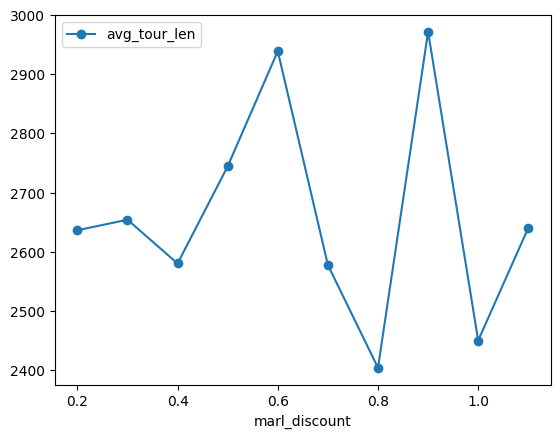

In [218]:
import pandas as pd
df = pd.DataFrame(results)
df.plot(x="marl_discount", y="avg_tour_len", marker="o")

## Beta 

In [212]:
results = []
for _ in range(10):
    ga_config.marl_softmax_beta += 1
    initial_population = marl_initial_population(ga_config, solver.n_cities, distance_matrix)
    print(f"Pop len {len(initial_population)}")
    avg_distance = np.mean([tour_distance(tour, distance_matrix) for tour in initial_population])
    results.append({"marl_softmax_beta": ga_config.marl_softmax_beta, "avg_tour_len": avg_distance})

Pop len 16
Pop len 13
Pop len 14
Pop len 16
Pop len 25
Pop len 27
Pop len 28
Pop len 21
Pop len 16
Pop len 30


<Axes: xlabel='marl_softmax_beta'>

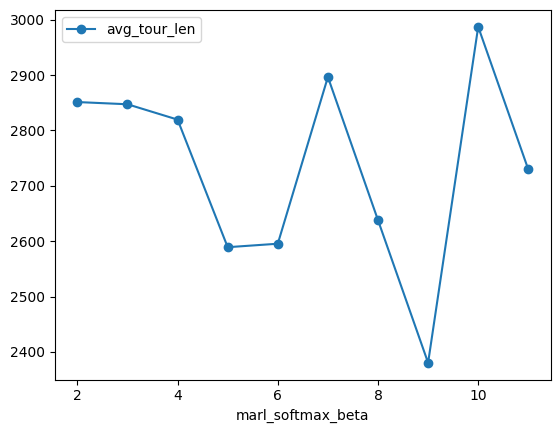

In [214]:
import pandas as pd
df = pd.DataFrame(results)
df.plot(x="marl_softmax_beta", y="avg_tour_len", marker="o")

## Epsilon mix

In [220]:
results = []
for _ in range(10):
    ga_config.marl_epsilon_mix += 0.1
    initial_population = marl_initial_population(ga_config, solver.n_cities, distance_matrix)
    print(f"Pop len {len(initial_population)}")
    avg_distance = np.mean([tour_distance(tour, distance_matrix) for tour in initial_population])
    results.append({"marl_epsilon_mix": ga_config.marl_epsilon_mix, "avg_tour_len": avg_distance})

Pop len 11


KeyboardInterrupt: 

<Axes: xlabel='marl_epsilon_mix'>

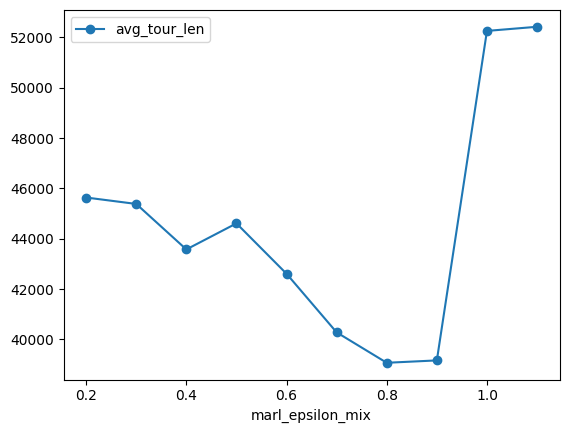

In [187]:
import pandas as pd
df = pd.DataFrame(results)
df.plot(x="marl_epsilon_mix", y="avg_tour_len", marker="o")

## Alpha

In [357]:
results = []
for _ in range(20):
    ga_config.marl_learning_rate += 0.05
    initial_population = marl_initial_population(ga_config, solver.n_cities, distance_matrix)
    print(f"Pop len {len(initial_population)}")
    avg_distance = np.mean([tour_distance(tour, distance_matrix) for tour in initial_population])
    results.append({"alpha": ga_config.marl_learning_rate, "avg_tour_len": avg_distance})

Adding Candidate with distance 910.0
Adding Candidate with distance 867.0
Adding Candidate with distance 863.0
Adding Candidate with distance 844.0
Adding Candidate with distance 836.0
Adding Candidate with distance 808.0
Adding Candidate with distance 774.0
Adding Candidate with distance 698.0
Pop len 8
Adding Candidate with distance 978.0
Adding Candidate with distance 971.0
Adding Candidate with distance 943.0
Adding Candidate with distance 936.0
Adding Candidate with distance 845.0
Adding Candidate with distance 833.0
Adding Candidate with distance 826.0
Adding Candidate with distance 786.0
Adding Candidate with distance 772.0
Pop len 9
Adding Candidate with distance 984.0
Adding Candidate with distance 973.0
Adding Candidate with distance 914.0
Adding Candidate with distance 869.0
Adding Candidate with distance 813.0
Adding Candidate with distance 795.0
Adding Candidate with distance 748.0
Adding Candidate with distance 719.0
Pop len 8
Adding Candidate with distance 956.0
Adding C

<Axes: xlabel='alpha'>

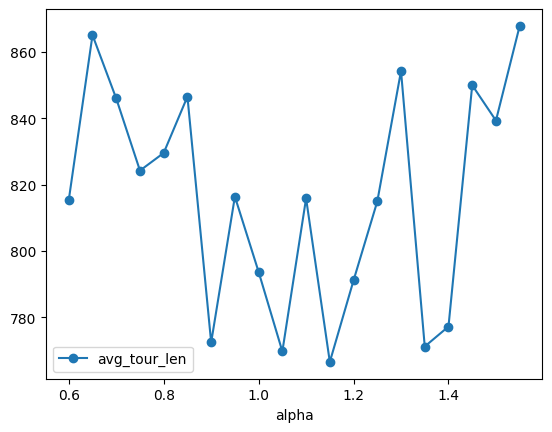

In [359]:
import pandas as pd
df = pd.DataFrame(results)
df.plot(x="alpha", y="avg_tour_len", marker="o")

In [239]:
initial_population = marl_initial_population(ga_config, solver.n_cities, distance_matrix)
distances = np.asarray(
    [tour_distance(tour, distance_matrix) for tour in initial_population], dtype=float
 )

print(f"Population members generated: {len(initial_population)}")
print(
    f"Distance stats -> min: {distances.min():.2f}, avg: {distances.mean():.2f}, std: {distances.std():.2f}"
 )
print("First tour preview:", initial_population[0][:10])

# basic sanity checks
assert all(len(tour) == solver.n_cities for tour in initial_population)
assert len(initial_population) <= ga_config.population_size

Population members generated: 26
Distance stats -> min: 2551.00, avg: 2810.46, std: 168.48
First tour preview: [13 16 37 35 34 33 32 36 31 30]


In [240]:
distances

array([2551., 2603., 2606., 2726., 2718., 2719., 2723., 2710., 2723.,
       2712., 2718., 2665., 2712., 2647., 2707., 2813., 2815., 2934.,
       2941., 2933., 3016., 3014., 3049., 3092., 3124., 3101.])

**Softmax sampling intuition**
- Build `weights` by running softmax on the Q-values for the still-available cities, so higher-Q actions get proportionally larger masses but lower-Q actions remain selectable.
- Draw a single uniform `threshold∈[0,1)`, then walk the `weights` cumulatively; the first bucket whose cumulative sum exceeds the threshold is the sampled city.
- The final `return available[-1]` line is a safety hatch for numeric edge cases (e.g., rounding leaves `cumulative < threshold`), ensuring a valid city is always returned.

### Verifying the triangular tour distance
1. Build a solver so we reuse the same triangular matrix used in production.
2. Pick any tour (nearest-neighbour, random, etc.).
3. Measure it two ways: (a) new triangular lookup, (b) fully symmetric matrix lookup. They must match and both be finite.

In [76]:
from pathlib import Path
import numpy as np

graph = Graph.from_tsplib(repo_root / "instances" / "tsplib" / "berlin52.tsp")
ga_cfg = GeneticAlgorithmConfig(population_size=10, seed=0)
ga_solver = GeneticTSPSolver(graph, ga_cfg)

tri_matrix = ga_solver.distance_matrix
full_matrix = np.asarray(graph.build_adj_matrix_full(), dtype=float)

nn_tour = nearest_neighbour_tour(graph)
open_tour = nn_tour[:-1]  # GA stores tours without repeating the start

def triangular_distance(tour: np.ndarray) -> float:
    cycle = ga_solver._close_tour(tour)
    rolled = np.roll(cycle, -1)
    lower = np.minimum(cycle, rolled)
    upper = np.maximum(cycle, rolled)
    return float(np.sum(tri_matrix[lower, upper]))

def full_distance(tour: np.ndarray) -> float:
    cycle = ga_solver._close_tour(tour)
    rolled = np.roll(cycle, -1)
    return float(np.sum(full_matrix[cycle, rolled]))

tri_val = triangular_distance(open_tour)
full_val = full_distance(open_tour)

print(f"Triangular matrix distance: {tri_val:.2f}")
print(f"Full matrix distance      : {full_val:.2f}")
print("Match?", np.isclose(tri_val, full_val))
print("Finite?", np.isfinite(tri_val) and np.isfinite(full_val))

Triangular matrix distance: 17519.00
Full matrix distance      : 17519.00
Match? True
Finite? True


## Testing crossover

In [185]:
from typing import Tuple
func_random = random.Random(123)

def ordered_crossover(
     parent1: np.ndarray, parent2: np.ndarray
) -> Tuple[np.ndarray, np.ndarray]:
    
    size = len(parent1)
    a, b = sorted(random.sample(range(size), 2))
    print(f"Randomn indices sorted {a} and {b}")

    def make_child(first: np.ndarray, second: np.ndarray) -> np.ndarray:
        child = -np.ones(size, dtype=int)
        child[a:b] = first[a:b]
        print(child)
        fill_pointer = b
        for gene in second:
            if gene in child:
                continue
            if fill_pointer >= size:
                fill_pointer = 0
            child[fill_pointer] = gene
            print(child)
            fill_pointer += 1
        return child

    return make_child(parent1, parent2), make_child(parent2, parent1)

In [186]:
p1 = np.array([0, 1, 2, 3, 4, 5])
p2 = np.array([5, 4, 3, 2, 1, 0])
child1, child2 = ordered_crossover(p1, p2)

Randomn indices sorted 2 and 4
[-1 -1  2  3 -1 -1]
[-1 -1  2  3  5 -1]
[-1 -1  2  3  5  4]
[ 1 -1  2  3  5  4]
[1 0 2 3 5 4]
[-1 -1  3  2 -1 -1]
[-1 -1  3  2  0 -1]
[-1 -1  3  2  0  1]
[ 4 -1  3  2  0  1]
[4 5 3 2 0 1]


In [ ]:
## Solution evolution example

## Solution evolution example

In [346]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

path_full ="/Users/karinaassiniandreatta/Documents/01 phd/codes/tsp_rl_metaheuristic/outputs/solutions/eil51/GeneticTSPSolver/marl/20251231_203241/20251231_203241_solution_81072_4537621136.json"
path = Path(path_full)
data = json.loads(path.read_text())
history = data["params"]["history"]

In [347]:
generations = [entry["generation"] for entry in history]
best_distances = [entry["best_distance"] for entry in history]

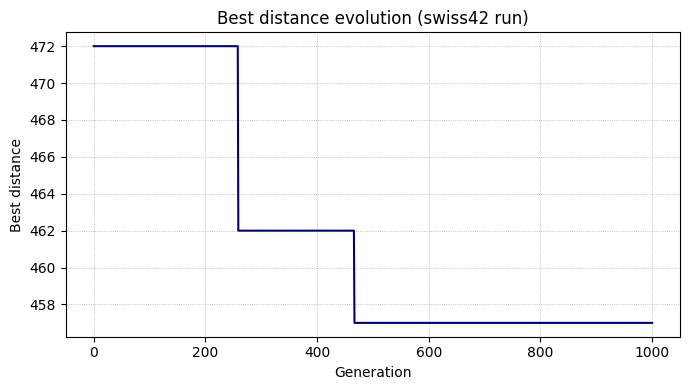

In [348]:
plt.figure(figsize=(7,4))
plt.plot(generations, best_distances, color="navy", linewidth=1.5)
plt.title("Best distance evolution (swiss42 run)")
plt.xlabel("Generation")
plt.ylabel("Best distance")
plt.grid(True, linestyle=":", linewidth=0.6)
plt.tight_layout()
plt.show()

In [ ]:
## Two opt 

# Two Opt

In [2]:
def _close_tour(tour: np.ndarray) -> np.ndarray:
    if tour[0] == tour[-1]:
        return tour
    return np.append(tour, tour[0])

def tour_distance(tour: np.ndarray, distance_matrix) -> float:
    cycle = _close_tour(tour)
    rolled = np.roll(cycle, -1)
    lower = np.minimum(cycle, rolled)
    upper = np.maximum(cycle, rolled)
    return float(np.sum(distance_matrix[lower, upper]))

def two_opt_improve(tour: np.ndarray, passes: int, distance_matrix) -> np.ndarray:
    """Classic 2-opt post-optimization over an open tour sequence."""

    best = tour.copy()
    best_distance = tour_distance(best, distance_matrix)
    length = len(best)
    max_passes = max(1, passes)

    for _ in range(max_passes):
        improved = False
        for i in range(length - 2):
            for j in range(i + 2, length):
                # Avoid breaking the implicit cycle link between first and last nodes.
                if i == 0 and j == length - 1:
                    continue
                candidate = best.copy()
                candidate[i : j + 1] = candidate[i : j + 1][::-1]
                candidate_distance = tour_distance(candidate)
                if candidate_distance + 1e-9 < best_distance:
                    best = candidate
                    best_distance = candidate_distance
                    improved = True
                    break
            if improved:
                break
        if not improved:
            break

        return best

In [4]:
from typing import Optional

In [25]:
def two_opt_junction_links(
    graph,
    tour: np.ndarray,
    max_junction_swaps: Optional[int] = None,
    distance_matrix: Optional[np.ndarray] = None,
) -> np.ndarray:
    """Run 2-opt swaps only on intersecting edges (junction links) per MARL paper."""

    coords = getattr(graph, "coords", None)
    fallback_passes = max(
        1,
        int(max_junction_swaps or 2 or 1),
    )
    if not coords:
        return two_opt_improve(tour, fallback_passes)

    if any(coords[int(node)] is None for node in tour):
        return two_opt_improve(tour, fallback_passes, distance_matrix)

    improved = tour.copy()
    n = len(improved)
    if n < 4:
        return improved

    limit = max(1, fallback_passes)

    def orientation(p: tuple[float, float], q: tuple[float, float], r: tuple[float, float]) -> float:
        return (q[0] - p[0]) * (r[1] - p[1]) - (q[1] - p[1]) * (r[0] - p[0])

    def edges_cross(a_idx: int, b_idx: int, c_idx: int, d_idx: int) -> bool:
        pa = coords[a_idx]
        pb = coords[b_idx]
        pc = coords[c_idx]
        pd = coords[d_idx]
        if pa is None or pb is None or pc is None or pd is None:
            return False
        o1 = orientation(pa, pb, pc)
        o2 = orientation(pa, pb, pd)
        o3 = orientation(pc, pd, pa)
        o4 = orientation(pc, pd, pb)
        eps = 1e-9
        return (o1 * o2 < -eps) and (o3 * o4 < -eps)

    swaps = 0
    while swaps < limit:
        improved_this_pass = False
        print(f"Actual Tour {improved}")
        for i in range(n):
            a_idx = int(improved[i])
            b_idx = int(improved[(i + 1) % n])
            print(f"Checking edges from {a_idx} to {b_idx}")
            for j in range(i + 2, n):
                if i == 0 and j == n - 1:
                    continue
                c_idx = int(improved[j])
                d_idx = int(improved[(j + 1) % n])
                if len({a_idx, b_idx, c_idx, d_idx}) < 4:
                    continue
                if edges_cross(a_idx, b_idx, c_idx, d_idx):
                    print(f"Edges ({a_idx},{b_idx}) and ({c_idx},{d_idx}) cross. Performing 2-opt swap.")
                    print(improved[i + 1 : j + 1])
                    print(improved[i + 1 : j + 1][::-1])
                    improved[i + 1 : j + 1] = improved[i + 1 : j + 1][::-1]
                    swaps += 1
                    improved_this_pass = True
                    break
            if improved_this_pass or swaps >= limit:
                break
        if not improved_this_pass:
            break
    return improved

In [26]:
from src.structures.graph import Graph
from src.solver.genetic_algorithm import GeneticTSPSolver, GeneticAlgorithmConfig

instance_path = repo_root / "instances" / "tsplib" / "eil51.tsp"
graph = Graph.from_tsplib(instance_path)

cfg = GeneticAlgorithmConfig(initialization_method="nearest_random")
solver = GeneticTSPSolver(graph, config=cfg, save_dir="/Users/karinaassiniandreatta/Documents/01 phd/codes/tsp_rl_metaheuristic/notebooks")
distance_matrix = solver.distance_matrix

In [27]:
distance_matrix

array([[ 0., 12., 19., ..., 26., 24., 14.],
       [12.,  0., 15., ..., 21., 14., 21.],
       [19., 15.,  0., ..., 36., 27., 33.],
       ...,
       [26., 21., 36., ...,  0., 12., 22.],
       [24., 14., 27., ..., 12.,  0., 26.],
       [14., 21., 33., ..., 22., 26.,  0.]], shape=(51, 51))

In [28]:
base = solver._nearest_random_individual()
test_tour = base.copy()

In [29]:
test_tour

array([11, 46, 50,  0, 31, 45, 47, 48, 49,  1, 15, 28, 33, 37, 38, 44,  2,
       19, 34, 35, 36, 43,  3, 16, 17, 24, 40, 41, 42,  4, 10, 26, 30, 32,
       39,  5, 13, 23, 25, 27, 29,  6, 22,  7, 21,  8,  9, 14, 18, 20, 12])

In [30]:
before = solver._tour_distance(test_tour)
improved = two_opt_junction_links(graph, test_tour.copy(), max_junction_swaps=5, distance_matrix=distance_matrix)
after = solver._tour_distance(improved)

print(f"Before: {before:.2f}, After: {after:.2f}")
print("Changed?", not np.array_equal(test_tour, improved))

Actual Tour [11 46 50  0 31 45 47 48 49  1 15 28 33 37 38 44  2 19 34 35 36 43  3 16
 17 24 40 41 42  4 10 26 30 32 39  5 13 23 25 27 29  6 22  7 21  8  9 14
 18 20 12]
Checking edges from 11 to 46
Edges (11,46) and (20,12) cross. Performing 2-opt swap.
[46 50  0 31 45 47 48 49  1 15 28 33 37 38 44  2 19 34 35 36 43  3 16 17
 24 40 41 42  4 10 26 30 32 39  5 13 23 25 27 29  6 22  7 21  8  9 14 18
 20]
[20 18 14  9  8 21  7 22  6 29 27 25 23 13  5 39 32 30 26 10  4 42 41 40
 24 17 16  3 43 36 35 34 19  2 44 38 37 33 28 15  1 49 48 47 45 31  0 50
 46]
Actual Tour [11 20 18 14  9  8 21  7 22  6 29 27 25 23 13  5 39 32 30 26 10  4 42 41
 40 24 17 16  3 43 36 35 34 19  2 44 38 37 33 28 15  1 49 48 47 45 31  0
 50 46 12]
Checking edges from 11 to 20
Edges (11,20) and (8,21) cross. Performing 2-opt swap.
[20 18 14  9  8]
[ 8  9 14 18 20]
Actual Tour [11  8  9 14 18 20 21  7 22  6 29 27 25 23 13  5 39 32 30 26 10  4 42 41
 40 24 17 16  3 43 36 35 34 19  2 44 38 37 33 28 15  1 49 48 47 45 31  0

In [ ]:
# Propa 

# Proba Softmax

In [31]:

import numpy as np

def marl_softmax(state, available, q_table, dist_matrix, beta=2.0):
    q_values = np.asarray([q_table[state, idx] for idx in available], dtype=float)
    inv_d = np.asarray([1.0 / max(dist_matrix[state, idx], 1e-9) for idx in available], dtype=float)
    energy = q_values * np.power(inv_d, max(0.1, beta))
    energy -= float(np.max(energy))  # numerical stability
    exp_values = np.exp(energy)
    total = float(np.sum(exp_values))
    if total <= 0:
        return [1.0 / len(available)] * len(available)
    return (exp_values / total).tolist()





In [ ]:
# --- Small sample: 4-city toy, state=0, actions {1,2,3}
q = np.array([[0, 1.0, 0.5, 0.2],
              [0.8, 0, 0.3, 0.6],
              [0.4, 0.7, 0, 0.9],
              [0.5, 0.1, 0.2, 0]])

# symmetric distances
d = np.array([[0, 10, 20, 30],
              [10, 0, 15, 25],
              [20, 15, 0, 18],
              [30, 25, 18, 0]], dtype=float)



In [34]:
available = [1, 2, 3]


In [33]:
# β sweep (shows concentration increases with β)
# β sensitivity: As β grows, the distribution flattens here because
#  inverse distances are modest and Q dominates; 
for beta in [0.5, 1.0, 2.0, 4.0]:
    probs = marl_softmax(0, available, q, d, beta=beta)
    print(f"beta={beta}: probs={probs} sum={sum(probs):.6f}")

# Equal-Q case: probabilities should reflect only distances and β
# with equal Q, β increases the preference for the nearest neighbor.
q_equal = np.ones((4, 4))
for beta in [0.5, 2.0]:
    probs = marl_softmax(0, available, q_equal, d, beta=beta)
    print(f"equal Q, beta={beta}: probs={probs}")

# Edge case: near-zero distance drives probability to that action
# Edge case stability: Near‑zero distance collapses probability as expected.
d_small = d.copy()
d_small[0, 1] = 1e-12  # almost overlapping cities 0 and 1
probs = marl_softmax(0, available, q, d_small, beta=2.0)
print(f"near-zero distance: probs={probs}")

beta=0.5: probs=[0.38893599598829615, 0.3170281046676106, 0.2940358993440932] sum=1.000000
beta=1.0: probs=[0.35228220491184253, 0.3268275209564224, 0.32089027413173504] sum=1.000000
beta=2.0: probs=[0.33539511452816445, 0.3324732092539583, 0.3321316762178772] sum=1.000000
beta=4.0: probs=[0.3333551812562363, 0.33332288903723173, 0.3333219297065319] sum=1.000000
equal Q, beta=0.5: probs=[0.35888189248426444, 0.3271348187870236, 0.313983288728712]
equal Q, beta=2.0: probs=[0.33515674743888924, 0.33265247459503, 0.33219077796608076]
near-zero distance: probs=[1.0, 0.0, 0.0]


# Test SMX

In [38]:
import numpy as np
import random

def smx_crossover(parent1: np.ndarray, parent2: np.ndarray) -> np.ndarray:
    """Sequential mixing crossover following the reference SMX flow chart."""

    size = len(parent1)
    offspring = -np.ones(size, dtype=int)
    parents = (parent1, parent2)
    parent_positions = [0, 0]  # how far we have read from each parent
    parent_index = 0  # which parent we currently pull from
    offspring_pos = 0  # next write position in the child
    seen: set[int] = set()  # genes already placed

    configured_segment = None
    if configured_segment is None or configured_segment <= 0:
        configured_segment = max(1, size // 4)
    max_segment = min(size, configured_segment)

    while offspring_pos < size:
        # If the active parent is exhausted, try the other; stop if both are done.
        if parent_positions[parent_index] >= size:
            other_index = 1 - parent_index
            if parent_positions[other_index] >= size:
                break
            parent_index = other_index
            continue

        # Choose how many consecutive genes to copy from the current parent.
        segment_len = random.randint(1, max_segment)
        print(f"Segment length: {segment_len}")
        inserted_this_round = 0
        parent = parents[parent_index]
        pos = parent_positions[parent_index]

        # Stream genes from the current parent, skipping duplicates, until the segment ends.
        while (
            pos < size
            and inserted_this_round < segment_len
            and offspring_pos < size
    ):
            
            gene = int(parent[pos])
            print(f"Considering gene {gene} from parent {parent_index} at pos {pos}")
            pos += 1
            if gene in seen:
                continue  # skip already placed genes
            offspring[offspring_pos] = gene
            offspring_pos += 1
            seen.add(gene)
            inserted_this_round += 1

        parent_positions[parent_index] = pos
        parent_index = 1 - parent_index  # alternate parents for the next segment

        # If nothing was inserted and both parents are spent, leave the loop.
        if inserted_this_round == 0 and parent_positions[0] >= size and parent_positions[1] >= size:
            break

    # Fill any remaining slots with unseen genes in parent order (fallback completion).
    if offspring_pos < size:
        for parent in parents:
            for gene in parent:
                gene = int(gene)
                if gene in seen:
                    continue
                offspring[offspring_pos] = gene
                offspring_pos += 1
                seen.add(gene)
                if offspring_pos == size:
                    break
            if offspring_pos == size:
                break

    if offspring_pos != size:
        raise ValueError("SMX crossover failed to construct a valid child tour")

    return offspring

In [39]:
parent1 = np.array([0, 1, 2, 3, 4, 5])
parent2 = np.array([5, 4, 3, 2, 1, 0])
child = smx_crossover(parent1, parent2)
print("Parent 1:", parent1)
print("Parent 2:", parent2)
print("Child   :", child)

Segment length: 1
Considering gene 0 from parent 0 at pos 0
Segment length: 1
Considering gene 5 from parent 1 at pos 0
Segment length: 1
Considering gene 1 from parent 0 at pos 1
Segment length: 1
Considering gene 4 from parent 1 at pos 1
Segment length: 1
Considering gene 2 from parent 0 at pos 2
Segment length: 1
Considering gene 3 from parent 1 at pos 2
Parent 1: [0 1 2 3 4 5]
Parent 2: [5 4 3 2 1 0]
Child   : [0 5 1 4 2 3]
